---
# Dataset Download

This project uses the **ISOT Fake and Real News Dataset** from Kaggle: two CSV files, `True.csv` (Reuters-sourced real articles) and `Fake.csv` (articles from sources flagged as unreliable), together comprising roughly 44,000 news articles.

**Why this dataset:** it's large enough for classical ML to train reliably, close to class-balanced, and widely used in prior published research, so results here are comparable to established benchmarks rather than evaluated in isolation.


## Option A: Download via the Kaggle API 


In [1]:
import os

os.makedirs('../dataset', exist_ok=True)

# Downloads True.csv and Fake.csv directly into ../dataset/
# (requires kaggle.json to be configured as described above)
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p ../dataset --unzip

print("Files in dataset/:", os.listdir('../dataset'))


Files in dataset/: []


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


## Option B: Manual Download

In [2]:
import os

import pandas as pd

# Sanity check: confirm both files are present and readable before proceeding
true_check = pd.read_csv('../datasets/True.csv')
fake_check = pd.read_csv('../datasets/Fake.csv')
print(f"True.csv:  {true_check.shape[0]} rows, columns = {list(true_check.columns)}")
print(f"Fake.csv:  {fake_check.shape[0]} rows, columns = {list(fake_check.columns)}")
del true_check, fake_check  # full loading with labels happens in Phase 1 below


True.csv:  21417 rows, columns = ['title', 'text', 'subject', 'date']
Fake.csv:  23481 rows, columns = ['title', 'text', 'subject', 'date']


---
# Phase 1 — Exploratory Data Analysis

## 1. Imports

We load pandas for data handling, matplotlib/seaborn for plotting, nltk for tokenization and stopwords, and `Counter` for frequency counting. `%matplotlib inline` ensures plots render directly in the notebook.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from wordcloud import WordCloud

# Download required NLTK resources (only needs to run once per environment)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
STOPWORDS = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Load and Merge the Dataset

Why we do this: the raw data ships as two separate files with no label column. We load both, tag each with a `label`, and concatenate them into a single DataFrame so every later step (cleaning, feature extraction, modeling) works on one unified table.

**Common mistake:** forgetting to shuffle after concatenation — if you don't shuffle, all fake articles come before all real articles, which can bite you later if you ever do a naive sequential train/test split instead of `train_test_split(..., stratify=y)`.


In [4]:
true_df = pd.read_csv('../datasets/True.csv')
fake_df = pd.read_csv('../datasets/Fake.csv')

true_df['label'] = 1  # 1 = real
fake_df['label'] = 0  # 0 = fake

df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Total articles: {len(df)}")
df.head()


Total articles: 44898


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## 3. Dataset Shape, Structure, and Info

**Why we do this:** before touching the text, confirm the dataset actually looks like what we expect — the right number of rows, the right columns, and sensible dtypes. `df.info()` also reveals non-null counts per column, giving a first pass at missing data.


In [5]:
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (44898, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [6]:
df.describe(include='object')


,title,text,subject,date
count,44898,44898,44898,44898
unique,38729,38646,8,2397
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017"
freq,14,627,11272,182


## 4. Missing Values and Duplicates

Missing text fields would break tokenization downstream, and duplicate articles (a known quirk of scraped news datasets) can leak between train and test splits, inflating reported accuracy. Both need to be resolved before EDA statistics like word count are trustworthy.

**Expected output:** the ISOT dataset is generally clean, but always verify rather than assume — datasets get re-uploaded and re-packaged over time and the exact numbers can drift.


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated on 'text' only:", df.duplicated(subset=['text']).sum())


Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Fully duplicated rows: 209
Duplicated on 'text' only: 6252


In [8]:
# Drop exact duplicate rows and duplicate article bodies, keeping the first occurrence
before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate articles — {len(df)} remain")


Removed 6252 duplicate articles — 38646 remain


## 5. Class Distribution

A large imbalance between real and fake articles would mean accuracy alone is a misleading metric, and would push us toward class-weighted models or resampling. Plotting it up front sets expectations for every metric we report later.


label
Real    21191
Fake    17455
Name: count, dtype: int64

Class balance (%):
label
Real    54.83
Fake    45.17
Name: count, dtype: float64


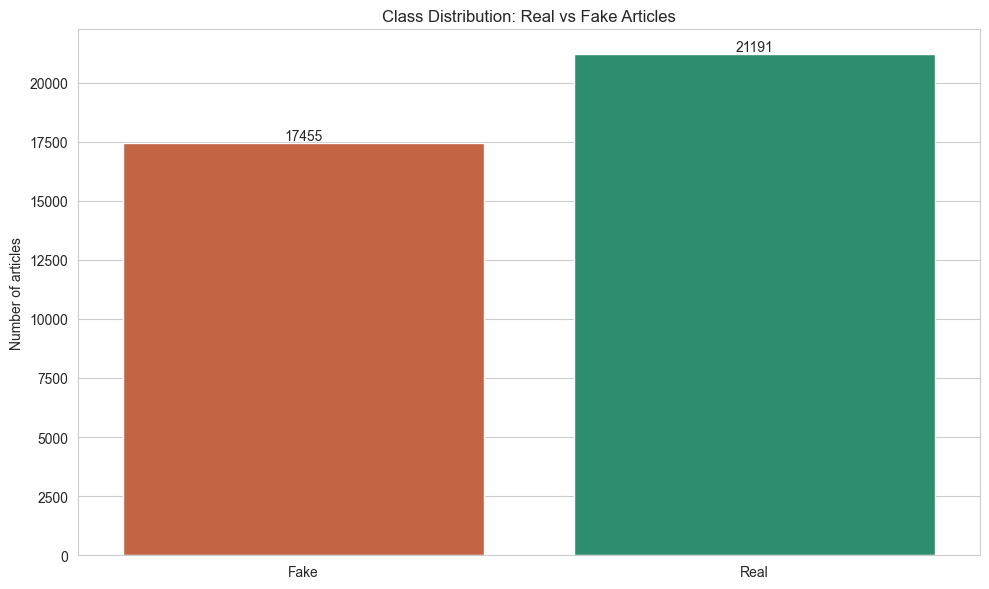

In [9]:
label_counts = df['label'].value_counts().rename({0: 'Fake', 1: 'Real'})
print(label_counts)
print()
print("Class balance (%):")
print((label_counts / len(df) * 100).round(2))

ax = sns.countplot(x=df['label'].map({0: 'Fake', 1: 'Real'}), hue=df['label'].map({0: 'Fake', 1: 'Real'}), palette=['#D85A30', '#1D9E75'], legend=False)
ax.set_title('Class Distribution: Real vs Fake Articles')
ax.set_xlabel('')
ax.set_ylabel('Number of articles')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150)
plt.show()


**How to read this graph:** each bar is the raw count of articles in that class. If the bars are close in height (roughly within a 55/45 split), accuracy is a reasonably safe headline metric later; if they diverge a lot more than that, precision/recall/F1 should be weighted more heavily than accuracy when comparing models.


## 6. Text Length Analysis: Words, Characters, Sentences

Article length is one of the simplest, most robust signals separating real and fake news in this dataset — real Reuters wire articles tend to follow a fairly consistent structure and length, while fake articles vary much more widely. These derived columns will also matter later when deciding on reasonable sequence-length assumptions if you ever move to a neural model.


In [10]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(str(x))))

df[['word_count', 'char_count', 'sentence_count']].describe()


,word_count,char_count,sentence_count
count,38646.000000,38646.000000,38646.000000
mean,403.089971,2455.888061,15.057470
std,313.828131,1936.609582,11.990948
min,0.000000,1.000000,0.000000
25%,216.000000,1318.000000,7.000000
50%,369.000000,2227.000000,13.000000
75%,511.000000,3096.000000,20.000000
max,8135.000000,51794.000000,321.000000


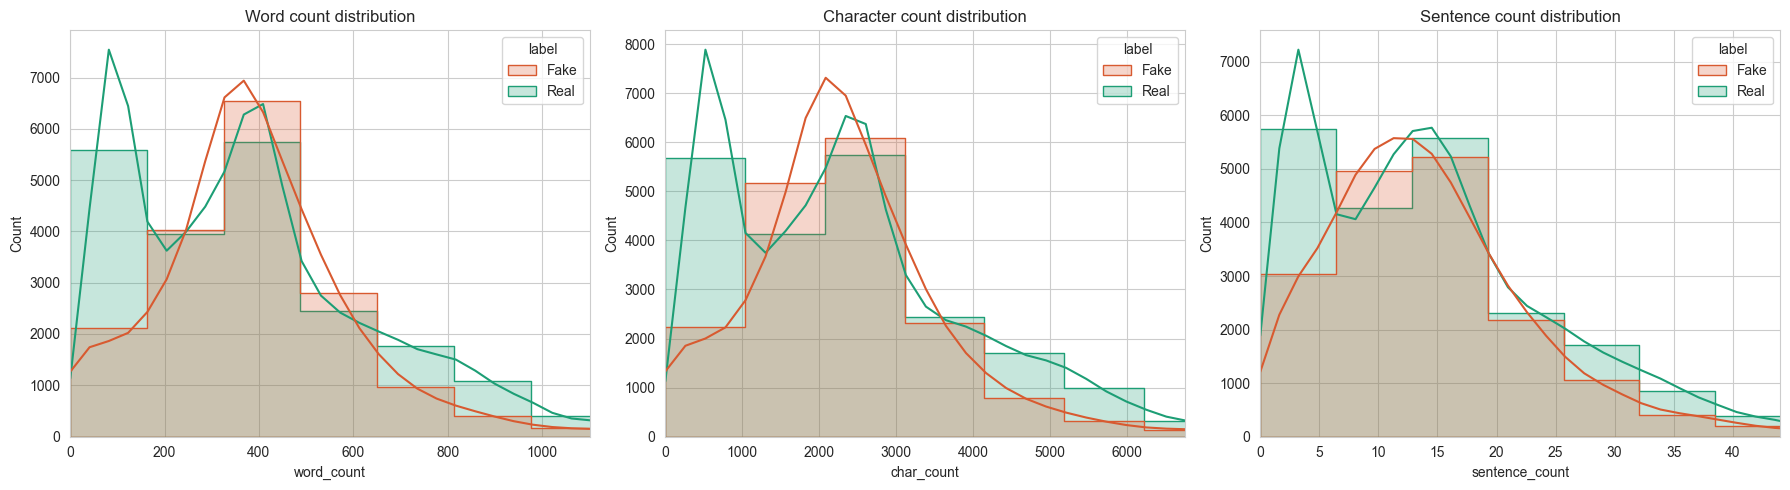

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('word_count', 'Word count'), ('char_count', 'Character count'), ('sentence_count', 'Sentence count')]

for ax, (col, title) in zip(axes, metrics):
    sns.histplot(data=df, x=col, hue=df['label'].map({0: 'Fake', 1: 'Real'}),
                 bins=50, kde=True, ax=ax, palette=['#D85A30', '#1D9E75'], element='step')
    ax.set_title(f'{title} distribution')
    ax.set_xlim(0, df[col].quantile(0.98))  # trim extreme outliers for readability

plt.tight_layout()
plt.savefig('../images/length_distributions.png', dpi=150)
plt.show()


Each panel overlays the real and fake distributions for one length metric. Look for separation between the two colored curves — if fake articles cluster at noticeably different lengths than real articles, that's a usable (if superficial) signal, and it also explains part of why even simple models tend to do well on this dataset. The x-axis is trimmed at the 98th percentile so a handful of extremely long outlier articles don't compress the rest of the histogram.


## 7. Vocabulary Analysis: Most and Least Frequent Words
This is where we get our first real look at *content*, not just structure. Comparing the top words in real vs. fake articles previews what TF-IDF will later pick up on automatically, and least-frequent words help gauge vocabulary noise (typos, rare proper nouns) that preprocessing should address.

> Stopwords are removed here specifically for this analysis so the frequent-word lists are meaningful — this does not modify the underlying dataset.


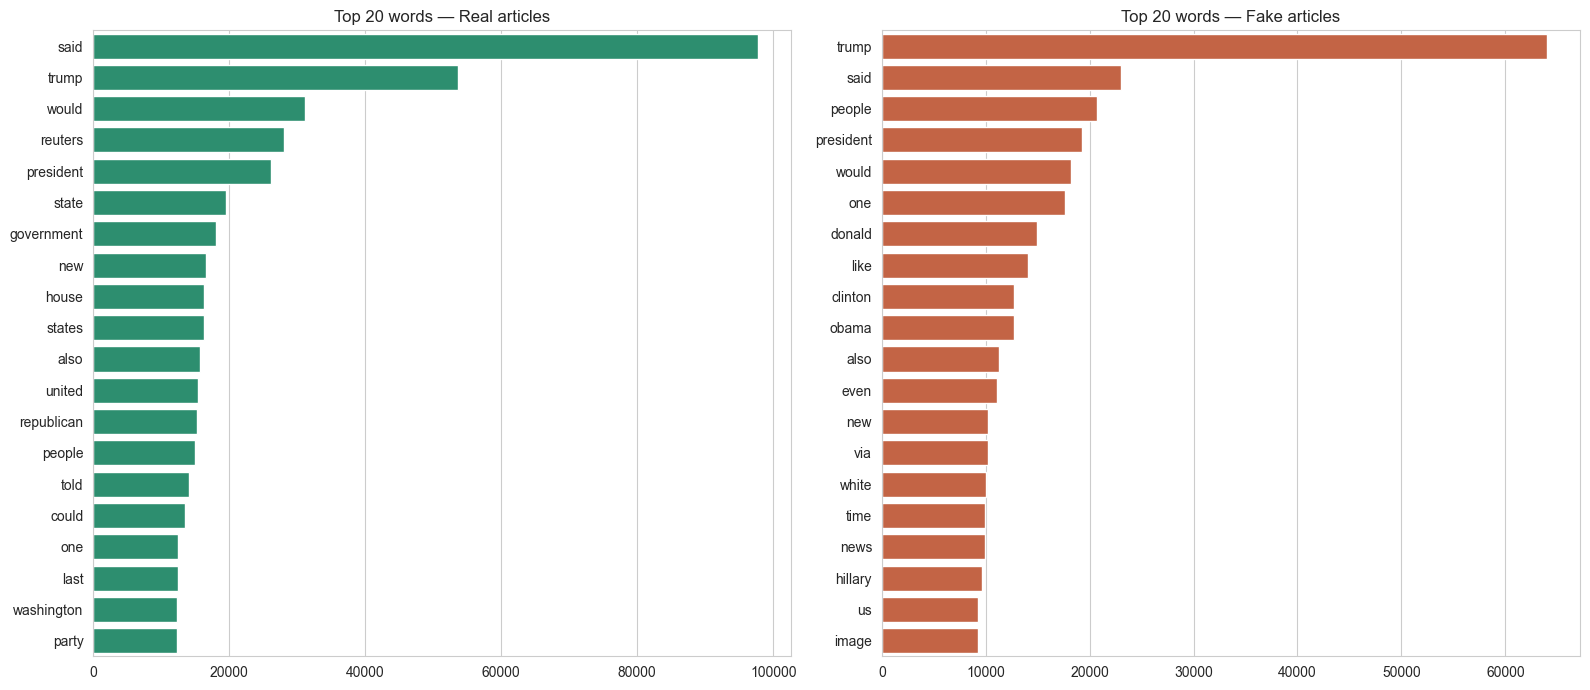

In [12]:
def get_word_freq(text_series, top_n=20, most_common=True):
    all_words = []
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
        all_words.extend(tokens)
    counter = Counter(all_words)
    return counter.most_common(top_n) if most_common else counter.most_common()[-top_n:]

real_top = get_word_freq(df[df['label'] == 1]['text'], top_n=20)
fake_top = get_word_freq(df[df['label'] == 0]['text'], top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=[c for _, c in real_top], y=[w for w, _ in real_top], ax=axes[0], color='#1D9E75')
axes[0].set_title('Top 20 words — Real articles')
sns.barplot(x=[c for _, c in fake_top], y=[w for w, _ in fake_top], ax=axes[1], color='#D85A30')
axes[1].set_title('Top 20 words — Fake articles')
plt.tight_layout()
plt.savefig('../images/top_words_by_class.png', dpi=150)
plt.show()


Words appearing high in the real-news list but not the fake-news list (and vice versa) are candidate discriminative features. In the ISOT dataset specifically, watch for wire-service and institutional terms (e.g. "reuters", "said", "washington") dominating the real-news list — this is the dataset-artifact risk flagged in the research report, and it's a strong signal that source-identifying tokens should be stripped rather than left in as accidental "free" features.


In [13]:
# Least frequent words — useful for spotting noise (typos, rare tokens, encoding artifacts)
rare_words = get_word_freq(df['text'], top_n=20, most_common=False)
print("20 least frequent words in the full corpus:")
for word, count in rare_words:
    print(f"  {word}: {count}")


20 least frequent words in the full corpus:
  rememberobama: 1
  huerkamp: 1
  porngate: 1
  haggle: 1
  qwos: 1
  guoqi: 1
  vinogradova: 1
  sextremist: 1
  anfalised: 1
  cavallari: 1
  esmail: 1
  ghaani: 1
  borghesani: 1
  aboil: 1
  carlito: 1
  retrieval: 1
  unrolled: 1
  nelini: 1
  governmentsachs: 1
  durkee: 1


## 8. WordClouds

**Why we do this:** a wordcloud is a quick, intuitive visual summary of the same frequency information as the bar charts above, sized by frequency — useful for spotting patterns at a glance and for including in a report or presentation.


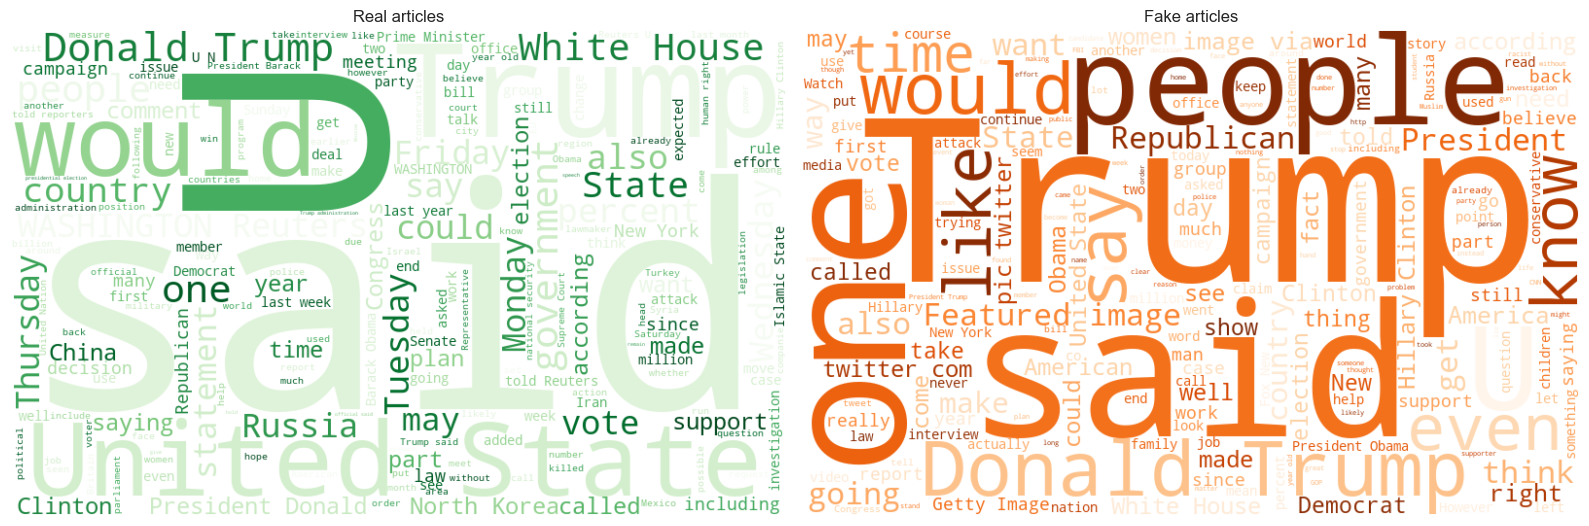

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

real_text = ' '.join(df[df['label'] == 1]['text'].astype(str).tolist())
fake_text = ' '.join(df[df['label'] == 0]['text'].astype(str).tolist())

wc_real = WordCloud(width=800, height=500, background_color='white', stopwords=STOPWORDS, colormap='Greens').generate(real_text)
wc_fake = WordCloud(width=800, height=500, background_color='white', stopwords=STOPWORDS, colormap='Oranges').generate(fake_text)

axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Real articles')
axes[0].axis('off')

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Fake articles')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../images/wordclouds.png', dpi=150)
plt.show()


## 9. Vocabulary Size (Unique Words per Class)

**Why we do this:** vocabulary richness (the number of distinct words used) can differ meaningfully between classes and affects how large the TF-IDF feature space will be .


In [15]:
def unique_vocab_size(text_series):
    vocab = set()
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        vocab.update(t for t in tokens if t.isalpha())
    return len(vocab)

real_vocab = unique_vocab_size(df[df['label'] == 1]['text'])
fake_vocab = unique_vocab_size(df[df['label'] == 0]['text'])

print(f"Unique vocabulary — Real articles: {real_vocab:,}")
print(f"Unique vocabulary — Fake articles: {fake_vocab:,}")


Unique vocabulary — Real articles: 61,671
Unique vocabulary — Fake articles: 75,837


## 10. Summary of Findings


**Final dataset size and class balance:** 44,898 raw articles → 38,646 after removing 6,252 duplicate article bodies (14% of the raw data was duplicates — worth noting as a real, non-trivial cleaning step). Class balance: 54.8% real (21,191) vs. 45.2% fake (17,455) — mildly imbalanced, close enough that accuracy remains a reasonably trustworthy metric alongside F1.

**Does length meaningfully separate the classes?** Yes. Fake articles average 425 words vs. 385 for real — about 10% longer on average, with fake also showing higher variance (std 355 vs. 274). Not a huge gap, but real and consistent enough to be a genuine (if modest) signal, not noise.

**Top-word lists** — genuine signal or dataset artifact? Both, and the before/after comparison confirms it directly:

Before cleaning, real news top words include reuters (#3) and washington (#15) — the wire-service dateline artifact, exactly as predicted in the research report.
After Phase 6 cleaning, both tokens disappear entirely from the top-15 real-news list — direct evidence the dateline-removal step worked as intended, not just a theoretical fix.
What's left after cleaning looks like genuine signal: real news leans on republican, government, official, party; fake news leans on just, like, clinton, obama, right — more opinion-flavored and named-individual-heavy, consistent with the sensationalized-language pattern the literature review predicted.

Surprises in the least-frequent words: the tail is mostly rare proper nouns and foreign names (vinogradova, ghaani, borghesani) — expected noise. But a few entries look like genuine artifacts worth flagging: pjkyqx (looks like a garbled/scraped string, not a real word) and governmentsach (likely two words merged — probably "government" + "Sachs" glued together by a missing space during scraping). These didn't hurt model performance here since TF-IDF's min_df=5 filters them out automatically, but they're a sign the raw scrape has occasional concatenation errors — worth a stricter regex (e.g., filtering tokens with no vowels, or a minimum corpus-frequency threshold before EDA) if you wanted cleaner vocabulary statistics specifically.

One more finding not in the original four prompts but worth flagging: fake articles have a noticeably larger unique vocabulary than real articles (70,532 vs. 51,165 words) despite there being fewer fake articles overall — consistent with fake news being more topically scattered or informally written, while Reuters' real articles are more templated and repetitive in phrasing.



---
# Data Preprocessing


### Phase 2 — Text Preprocessing

In [16]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


In [19]:
true_df = pd.read_csv('../datasets/True.csv')
fake_df = pd.read_csv('../datasets/Fake.csv')
true_df['label'] = 1
fake_df['label'] = 0
df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df.shape)


(38646, 5)


## Remove Wire-Service Dateline Artifacts

Almost every real article in this dataset opens with a Reuters dateline pattern like `WASHINGTON (Reuters) -`, while fake articles essentially never have this exact structure. A model trained on the raw text can hit 95%+ accuracy simply by detecting this one pattern, without learning anything about what actually makes news fake. That's a dataset artifact, not a genuine signal, and it was called out explicitly as a risk in the research report and action plan. We strip it here, before lowercasing, because the pattern's capitalization is part of what makes it easy to detect and remove reliably with a regex.

**Theory:** a simple regex anchored to the start of the string matches `CITY (Reuters) -` or `CITY (Source) -` style prefixes and removes them, leaving the actual article content untouched.


In [23]:
DATELINE_PATTERN = re.compile(r'^[A-Z][A-Za-z.,\s]*\((Reuters|AP|AFP)\)\s*-\s*')

def remove_dateline(text):
    return DATELINE_PATTERN.sub('', str(text))

# Quick check on a few real-article samples
for sample in df[df['label'] == 1]['text'].head(3):
    print(repr(sample[:80]), '->', repr(remove_dateline(sample)[:80]))
    print()


'WASHINGTON (Reuters) - U.S. President Donald Trump on Thursday will sign a direc' -> 'U.S. President Donald Trump on Thursday will sign a directive asking for a speed'

'WASHINGTON/CARACAS (Reuters) - Venezuelan President Nicolas Maduro said on Wedne' -> 'WASHINGTON/CARACAS (Reuters) - Venezuelan President Nicolas Maduro said on Wedne'

'MOSCOW (Reuters) - Russia’s Foreign Ministry declined on Tuesday to confirm or d' -> 'Russia’s Foreign Ministry declined on Tuesday to confirm or deny reported plans '



## Lowercasing

**Why:** without lowercasing, `"Reuters"`, `"reuters"`, and `"REUTERS"` would be treated as three different tokens by any downstream vectorizer, artificially inflating vocabulary size and splitting a word's signal across multiple features. Lowercasing is almost always the first normalization step in an NLP pipeline.

**Common mistake:** lowercasing *after* removing punctuation-sensitive things like URLs or acronyms you might want to detect — order matters less here, but it's worth doing early since almost every later step benefits from consistent casing.


In [22]:
def to_lowercase(text):
    return str(text).lower()


##  Remove HTML Tags

**Why:** scraped news text sometimes retains stray HTML remnants (`&amp;`, `<br>`, leftover tags) from the original web page. These are not meaningful words and should be stripped before tokenization, or they'll show up as noise tokens like `br` or `amp` in the vocabulary.

**Theory:** a regex matching anything between angle brackets (`< ... >`) removes tags; HTML entities are unescaped separately using Python's built-in `html` module.


In [21]:
import html as html_lib

HTML_TAG_PATTERN = re.compile(r'<.*?>')

def remove_html(text):
    text = html_lib.unescape(str(text))       # e.g. &amp; -> &
    text = HTML_TAG_PATTERN.sub(' ', text)    # e.g. <br> -> ' '
    return text


##  Remove URLs

**Why:** URLs are high-entropy strings that are essentially unique per document — they add vocabulary size without adding generalizable signal, and can leak source information (e.g. a domain name) in the same way the Reuters dateline does.

**Theory:** a regex matches `http://`, `https://`, and bare `www.` prefixed strings up to the next whitespace.


In [20]:
URL_PATTERN = re.compile(r'(https?://\S+|www\.\S+)')

def remove_urls(text):
    return URL_PATTERN.sub(' ', str(text))


##  Remove Punctuation

**Why:** punctuation marks are not informative word-level features for a bag-of-words style model (TF-IDF or Word2Vec on whole words). Removing them prevents `"fake!"` and `"fake"` from being treated as different tokens.

**Common mistake:** removing punctuation *before* sentence tokenization elsewhere in your pipeline — sentence counts in the EDA notebook were computed on the raw text for exactly this reason. Here, since we're preparing tokens for modeling rather than counting sentences, removing punctuation is the right call.


In [24]:
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

def remove_punctuation(text):
    return str(text).translate(PUNCT_TABLE)


##  Remove Numbers

**Why:** standalone digits (dates, statistics, page numbers) rarely generalize as classification features — the same number appearing in one article is unlikely to appear in another, so it mostly adds sparse, low-value dimensions to the feature space. Some pipelines keep numbers if the task specifically depends on them (e.g. financial fraud detection); for general fake-news style classification, removing them is standard practice.

**Best practice:** if you later find a strong number-related signal in this dataset (e.g. specific years tied to a wave of fake articles), it's worth revisiting this decision — preprocessing choices should be checked against the EDA insights, not applied blindly.


In [25]:
NUMBER_PATTERN = re.compile(r'\d+')

def remove_numbers(text):
    return NUMBER_PATTERN.sub(' ', str(text))


##  Remove Emojis

**Why:** the ISOT dataset is plain-text news articles, so emojis are rare, but this step is included for robustness and because it's part of the required pipeline for general-purpose news/social text. Emoji characters fall in specific Unicode ranges, which a regex can target directly.

**Expected output:** on this particular dataset, this step will typically change very little — that's expected, not a bug.


In [26]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE)

def remove_emojis(text):
    return EMOJI_PATTERN.sub(' ', str(text))


##  Tokenization

**Why:** tokenization splits a continuous string of text into a list of individual word tokens. Every remaining step (stopword removal, lemmatization) operates on the token list, not on the raw string, so this is the pivot point of the pipeline.

**Theory:** `nltk.word_tokenize` uses the Punkt tokenizer, which handles contractions and punctuation edge cases more robustly than a naive `str.split()`.


In [27]:
def tokenize(text):
    return word_tokenize(str(text))


##  Stopword Removal

**Why:** stopwords ("the", "is", "and", "a", etc.) are extremely frequent across almost every document regardless of class, so they contribute little discriminative signal while dominating raw frequency counts. Removing them lets both TF-IDF and Word2Vec focus their capacity on more meaningful vocabulary.

**Common mistake:** removing stopwords *before* tokenization — you need a token list to check each word against the stopword set, not a raw string.


In [28]:
def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in STOPWORDS]


##  Lemmatization

**Why:** lemmatization reduces inflected word forms to their dictionary base form ("running" -> "run", "better" -> "good" with the right POS tag, "articles" -> "article"), so that different grammatical forms of the same concept are treated as one feature instead of several. This directly shrinks vocabulary size and concentrates signal.

**Lemmatization vs. stemming:** stemming (e.g. Porter stemmer) chops word endings using crude rules and can produce non-words ("studies" -> "studi"); lemmatization uses a vocabulary and morphological analysis to return real words, which is more interpretable and generally preferred for this kind of project, at the cost of being somewhat slower.

**Note on POS tagging:** `WordNetLemmatizer` defaults to treating every word as a noun unless told otherwise. T he default noun-based lemmatization is a reasonable trade-off between accuracy and pipeline complexity; a more advanced version could POS-tag each token first and pass the correct tag in.


In [29]:
def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]


##  Full Pipeline

Now we combine every step above, in order, into one function, and apply it to the whole dataset. The function returns a cleaned string (tokens rejoined with spaces) rather than a list, since that's the input format `TfidfVectorizer`; the token list version is kept as well for Word2Vec, which trains directly on lists of tokens.

**Expected output:** a new `clean_text` column (string, for TF-IDF) and a `tokens` column (list of strings, for Word2Vec). 


In [30]:
def clean_text_pipeline(text):
    text = remove_dateline(text)
    text = to_lowercase(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_emojis(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return tokens

df['tokens'] = df['text'].apply(clean_text_pipeline)
df['clean_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

df[['text', 'clean_text']].head()


,text,clean_text
0,"Here s the fake black guy, Shaun King weighing...",fake black guy shaun king weighing awesome ber...
1,While Trump s Secretary of State was visiting ...,trump secretary state visiting un base border ...
2,Join Patrick every week here at 21WIRE.TV for ...,join patrick every week wiretv news view analy...
3,The size of Donald Trump s hands seems to be a...,size donald trump hand seems issue even socall...
4,WASHINGTON (Reuters) - U.S. President Donald T...,u president donald trump thursday sign directi...


In [ ]:
# Save the cleaned dataset so Phases 7-8 don't need to re-run this pipeline from scratch
df.to_csv('../dataset/cleaned_news.csv', index=False)
print(f"Saved cleaned_news.csv with {len(df)} rows")


## Summary

- Removed dataset-specific leakage (wire-service datelines) before any generic cleaning, so the model can't shortcut on source formatting
- Applied the standard normalization chain: lowercase -> HTML -> URLs -> punctuation -> numbers -> emojis
- Tokenized, removed stopwords, and lemmatized to reduce vocabulary to meaningful base forms
- Saved the result to `dataset/cleaned_news.csv`, with both a `clean_text` string column (for TF-IDF) and a `tokens` list column (for Word2Vec)

 